# Module 3.6 — Unsteady Flows and Time-Stepping

## The destination vs. the journey

In Module 2 (SIMPLE, lid-driven cavity), time-stepping was just a **trick to reach steady state**. You didn't care about the path — only the final answer. So you picked the largest $\Delta t$ that didn't blow up (stability), and threw away every intermediate step as "not converged yet."

**Analogy:** if you only care about *where* a car ends up parked, you can floor it, brake hard, swerve — any path that gets it into the spot is fine. Nobody is filming the drive.

Unsteady flows are different: **the journey is the answer**. A vortex shedding off a cylinder, blood pulsing through an artery, a turbine blade sweeping past a stator — the thing you want to capture *is* the time-history. Now $\Delta t$ can't just be "stable," it has to be **accurate** — small enough, and from a scheme good enough, that the in-between frames of the movie are trustworthy, not just the final frame.

**When a flow is genuinely unsteady (the movie matters, not just the ending):**
- Vortex shedding (Kármán street, cylinder flow)
- Turbomachinery (rotor-stator interaction, blade passing)
- Cardiovascular flows (pulsatile blood flow)
- Combustion instabilities and acoustic resonance
- Weather and ocean circulation (inherently transient)

**Roadmap:**
1. Explicit vs. implicit time integration — the accuracy vs. stability trade-off
2. Order of accuracy in time — what it means and why it matters
3. Stability regions — visualising when schemes blow up
4. Runge-Kutta methods — 4th order with only 4 function evaluations
5. Dual time-stepping — the practical approach for unsteady incompressible flows
6. Choosing $\Delta t$ — CFL for accuracy, not just stability

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Time Integration Schemes

### The model ODE

All analysis starts with the test equation $du/dt = \lambda u$ (complex $\lambda$). For CFD:
- Advection eigenvalues: $\lambda = -ic k\Delta x / \Delta t$ — purely imaginary
- Diffusion eigenvalues: $\lambda = -4r\sin^2(k\Delta x/2)$ — negative real

A scheme is stable if the amplification factor $|G| = |u^{n+1}/u^n| \leq 1$ for all relevant $\lambda\Delta t$.

### Common schemes — and the analogy behind each

**Forward Euler (explicit, 1st order):**
$$u^{n+1} = u^n + \Delta t\,F(u^n)$$
**Analogy:** driving while looking only at your *current* speedometer reading, then holding the wheel and gas pedal fixed for the next $\Delta t$ seconds no matter what the road does. Cheap, but if the road curves (the solution changes) before your next glance, you overshoot. Stability region: a small disk near the origin in the $\lambda\Delta t$-plane.

**Adams-Bashforth 2 (explicit, 2nd order):**
$$u^{n+1} = u^n + \Delta t\left(\frac{3}{2}F(u^n) - \frac{1}{2}F(u^{n-1})\right)$$
**Analogy:** same "eyes on the current instant" driving, but now you also remember *where you were heading a moment ago* and extrapolate the trend — like noticing the road has been curving left, so you lean into the turn slightly before it visibly bends. Still explicit (no peeking at the future), still similar stability limits, but the trend-correction buys a full extra order of accuracy for free.

**Crank-Nicolson (implicit, 2nd order, A-stable for diffusion):**
$$u^{n+1} = u^n + \frac{\Delta t}{2}\left[F(u^n) + F(u^{n+1})\right]$$
**Analogy:** you don't just look at where you are now — you also ask "where will I be at the end of this step?" and average the two slopes. That requires solving for the destination *before* you finish the step (an implicit equation), but the payoff is huge: it stays stable for diffusion no matter how big $\Delta t$ is. Trade-off: can ring/oscillate for pure advection with large steps, like overcorrecting a steering average.

**BDF2 (implicit, 2nd order):**
$$\frac{3u^{n+1} - 4u^n + u^{n-1}}{2\Delta t} = F(u^{n+1})$$
**Analogy:** like Crank-Nicolson's "ask the destination first," but instead of averaging old and new slopes it fits a smooth curve through the last *two* known points and the unknown new one, then demands that curve obey $F$ at the new point. More damping (it smooths out ringing) than CN — this is why OpenFOAM's `backward` scheme is the default workhorse for unsteady RANS.

**RK4 (explicit, 4th order):**
$$k_1 = F(u^n), \quad k_2 = F(u^n+\tfrac{\Delta t}{2}k_1), \quad k_3 = F(u^n+\tfrac{\Delta t}{2}k_2), \quad k_4 = F(u^n+\Delta t k_3)$$
$$u^{n+1} = u^n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$
**Analogy:** instead of one glance at the start of the step (Euler) or a trend (AB2), you send out four scouts within the step — one at the start, two probing the midpoint from different slopes, one at the projected endpoint — then average their slopes (weighted 1:2:2:1). Four function evaluations, but the curvature information from the scouts cancels out error terms up to 4th order. No implicit solve needed, yet far more accurate per step.

### Choosing $\Delta t$ for accuracy

For steady-state: choose the largest stable $\Delta t$ — you're racing to the destination, the route doesn't matter.

For time-accurate unsteady: choose $\Delta t$ based on the **physical time scale** you need to resolve — like choosing a camera frame rate to film a spinning fan without it looking like it's standing still (or spinning backwards). If the Kármán shedding frequency is $f = 2$ Hz and you want 100 frames per cycle: $\Delta t = 1/(100 \times 2) = 0.005$ s. Then check CFL is also satisfied.

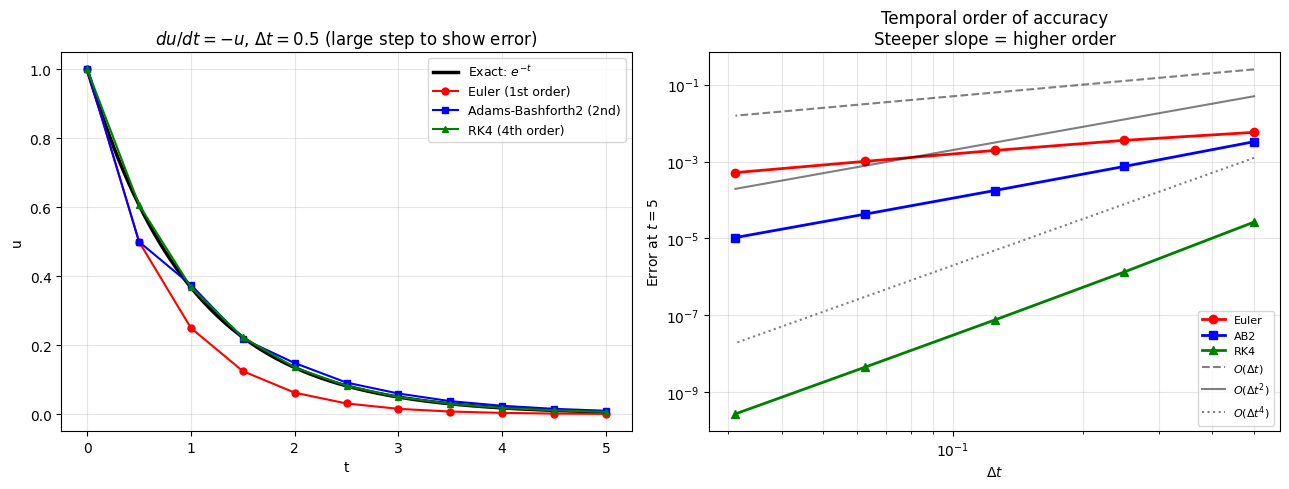

For the same Δt:
  Euler error: 0.0058
  AB2 error:   0.0033   (1.7× smaller)
  RK4 error:   0.000027   (216× smaller)


In [4]:
# ── Compare time integration schemes on du/dt = -u (exact: u = exp(-t)) ───────

def euler_fwd(u0, dt, T):
    u, t, us, ts = u0, 0.0, [u0], [0.0]
    while t < T:
        u += dt*(-u); t += dt
        us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

def adams_bashforth2(u0, dt, T):
    u, t = u0, 0.0
    F_old = -u0
    u += dt*F_old; t += dt   # Euler first step
    us, ts = [u0, u], [0.0, t]
    while t < T:
        F_new = -u
        u = u + dt*(1.5*F_new - 0.5*F_old)
        F_old = F_new; t += dt
        us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

def rk4(u0, dt, T):
    u, t, us, ts = u0, 0.0, [u0], [0.0]
    while t < T:
        k1 = -u
        k2 = -(u + dt/2*k1)
        k3 = -(u + dt/2*k2)
        k4 = -(u + dt*k3)
        u += dt/6*(k1 + 2*k2 + 2*k3 + k4)
        t += dt; us.append(u); ts.append(t)
    return np.array(ts), np.array(us)

T   = 5.0
dt  = 0.5   # large time step to show accuracy differences
t_ex = np.linspace(0, T, 300)
u_ex = np.exp(-t_ex)

t_eu, u_eu = euler_fwd(1.0, dt, T)
t_ab, u_ab = adams_bashforth2(1.0, dt, T)
t_rk, u_rk = rk4(1.0, dt, T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trajectory
axes[0].plot(t_ex, u_ex,  'k-', lw=2.5, label='Exact: $e^{-t}$')
axes[0].plot(t_eu, u_eu, 'r-o', ms=5, lw=1.5, label='Euler (1st order)')
axes[0].plot(t_ab, u_ab, 'b-s', ms=5, lw=1.5, label='Adams-Bashforth2 (2nd)')
axes[0].plot(t_rk, u_rk, 'g-^', ms=5, lw=1.5, label='RK4 (4th order)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('u')
axes[0].set_title(f'$du/dt = -u$, $\\Delta t = {dt}$ (large step to show error)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Convergence
dt_vals = [0.5, 0.25, 0.125, 0.0625, 0.03125]
u_ref   = np.exp(-T)
errs_eu = [abs(euler_fwd(1.0, dt, T)[1][-1] - u_ref)         for dt in dt_vals]
errs_ab = [abs(adams_bashforth2(1.0, dt, T)[1][-1] - u_ref)  for dt in dt_vals]
errs_rk = [abs(rk4(1.0, dt, T)[1][-1] - u_ref)               for dt in dt_vals]

dts = np.array(dt_vals)
axes[1].loglog(dts, errs_eu, 'r-o', ms=6, lw=2, label='Euler')
axes[1].loglog(dts, errs_ab, 'b-s', ms=6, lw=2, label='AB2')
axes[1].loglog(dts, errs_rk, 'g-^', ms=6, lw=2, label='RK4')
axes[1].loglog(dts, 0.5*dts**1,  'k--', alpha=0.5, label='$O(\\Delta t)$')
axes[1].loglog(dts, 0.2*dts**2,  'k-',  alpha=0.5, label='$O(\\Delta t^2)$')
axes[1].loglog(dts, 0.02*dts**4, 'k:',  alpha=0.5, label='$O(\\Delta t^4)$')
axes[1].set_xlabel('$\\Delta t$'); axes[1].set_ylabel('Error at $t=5$')
axes[1].set_title('Temporal order of accuracy\nSteeper slope = higher order')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print('For the same Δt:')
print(f'  Euler error: {errs_eu[0]:.4f}')
print(f'  AB2 error:   {errs_ab[0]:.4f}   ({errs_eu[0]/errs_ab[0]:.1f}× smaller)')
print(f'  RK4 error:   {errs_rk[0]:.6f}   ({errs_eu[0]/errs_rk[0]:.0f}× smaller)')

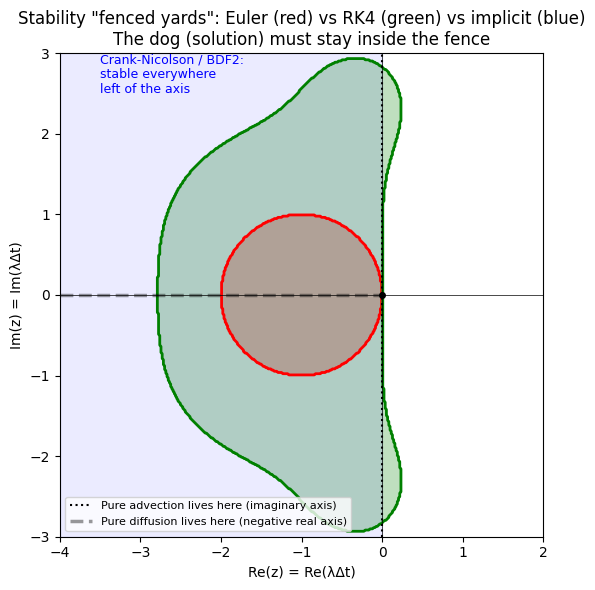

Forward Euler's yard only touches the imaginary axis at the single point z=0,
so for pure advection (which lives exactly on that axis) it is unstable for ANY Δt > 0.
RK4's yard bulges out to cover part of the imaginary axis -> usable for advection.
Implicit CN/BDF2 cover the entire left half-plane -> unconditionally stable for diffusion.


In [5]:
# ── The "fenced yard": stability regions in the z = λΔt plane ────────────────

x = np.linspace(-4, 2, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

def G_euler(z):  return 1 + z
def G_rk4(z):    return 1 + z + z**2/2 + z**3/6 + z**4/24

fig, ax = plt.subplots(figsize=(7, 6))

for G, name, color in [(G_euler, 'Forward Euler', 'red'), (G_rk4, 'RK4', 'green')]:
    mask = np.abs(G(Z)) <= 1.0
    ax.contourf(X, Y, mask, levels=[0.5, 1.5], colors=[color], alpha=0.25)
    ax.contour(X, Y, mask, levels=[0.5], colors=[color], linewidths=2)

# CN / BDF2: stable everywhere in the left half-plane (the whole left side is "inside the fence")
ax.axvspan(-4, 0, color='blue', alpha=0.08)
ax.text(-3.5, 2.5, 'Crank-Nicolson / BDF2:\nstable everywhere\nleft of the axis', color='blue', fontsize=9)

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.plot(0, 0, 'ko', ms=4)

# Mark where pure advection (imaginary axis) and pure diffusion (negative real axis) live
ax.plot([0, 0], [-3, 3], 'k:', lw=1.5, label='Pure advection lives here (imaginary axis)')
ax.plot([-4, 0], [0, 0], 'k--', lw=2.5, alpha=0.4, label='Pure diffusion lives here (negative real axis)')

ax.set_xlim(-4, 2); ax.set_ylim(-3, 3)
ax.set_xlabel('Re(z) = Re(λΔt)'); ax.set_ylabel('Im(z) = Im(λΔt)')
ax.set_title('Stability "fenced yards": Euler (red) vs RK4 (green) vs implicit (blue)\nThe dog (solution) must stay inside the fence')
ax.legend(fontsize=8, loc='lower left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print('Forward Euler\'s yard only touches the imaginary axis at the single point z=0,')
print('so for pure advection (which lives exactly on that axis) it is unstable for ANY Δt > 0.')
print('RK4\'s yard bulges out to cover part of the imaginary axis -> usable for advection.')
print('Implicit CN/BDF2 cover the entire left half-plane -> unconditionally stable for diffusion.')

## 2. Stability Regions — Visualising When Schemes Blow Up

### The amplification factor

For $du/dt = \lambda u$ with complex $\lambda$, define $z = \lambda\Delta t$. Then:

- **Forward Euler:** $G = 1 + z$
- **RK4:** $G = 1 + z + z^2/2 + z^3/6 + z^4/24$

Stability: $|G(z)| \leq 1$.

**Analogy — the fenced yard:** think of $z = \lambda\Delta t$ as "how big a step relative to how fast the dynamics are wiggling." The stability region is a fenced yard around the origin of the $z$-plane: as long as your step lands inside the fence, the dog (your solution) stays contained. Step too far ($\Delta t$ too large for that $\lambda$) and the dog jumps the fence — the solution diverges. Different schemes have differently shaped (and sized) yards.

**Physical interpretation of $z$:**
- For diffusion: $z = -r$ (real, negative) — must have $|z| \leq 2$ for Euler
- For advection: $z = -i\nu\cdot$(some factor) — imaginary — RK4 covers part of imaginary axis but Euler does not

**Consequence for CFD:**
- Euler's yard barely touches the imaginary axis at the origin — so for pure advection (which always lives exactly *on* the imaginary axis) it is unstable for any $\Delta t > 0$
- RK4's yard bulges out along the imaginary axis — stable for mild advection
- Implicit schemes (CN, BDF2) have a yard covering the *entire* left half-plane — unconditionally stable for diffusion, no matter how large $\Delta t$ is

## 3. Dual Time-Stepping for Unsteady Incompressible Flow

SIMPLE was designed for steady state — march in time only to converge to one final answer. For unsteady flows you want both: accurate *physical* time history, but SIMPLE's pressure-velocity coupling still needs several iterations to converge *within* each time step. **Dual time-stepping** resolves this by running two clocks.

**Analogy — a video game with two clocks:** the *physical* clock advances once per displayed frame (this is the time history you care about — $\Delta t$, chosen for accuracy). But to draw each frame correctly, the physics engine runs many fast internal sub-steps (collision resolution, constraint solving) on a separate, *fake* clock that has no physical meaning — it just exists to let the frame settle into a consistent state before being displayed. The pseudo-time $\tau$ is exactly that inner, fictitious clock.

```
OUTER LOOP (physical time t): small Δt for accuracy — this is the "frame"
  For each physical time step:
    INNER LOOP (pseudo-time τ): large Δτ for fast convergence — "settling the frame"
      Apply SIMPLE with large Δτ
      Repeat until inner residuals < tolerance
    → Solution at physical time t^{n+1} converged — frame is drawn, advance to next frame
```

The physical time derivative becomes a source term in the pseudo-time equation:

$$\frac{\partial\mathbf{u}}{\partial\tau} + \frac{3\mathbf{u}^{n+1} - 4\mathbf{u}^n + \mathbf{u}^{n-1}}{2\Delta t} + N(\mathbf{u}^{n+1}) = 0$$

This is BDF2 in physical time (2nd order accurate) plus pseudo-time advancement to converge the system.

**OpenFOAM:** `pimpleFoam` uses PIMPLE = PISO + SIMPLE with dual time-stepping.

## Summary

| Scheme | Order | Stability | Cost | When to use |
|--------|-------|-----------|------|-------------|
| Forward Euler | 1st | Limited | $O(N)$ | Only steady-state pseudo-time |
| Adams-Bashforth 2 | 2nd | Limited | $O(N)$ | Unsteady explicit, moderate accuracy |
| Crank-Nicolson | 2nd | A-stable (diffusion) | $O(N)$ + solve | High accuracy, smooth flows |
| BDF2 | 2nd | More damping | $O(N)$ + solve | Unsteady, stability preferred |
| RK4 | 4th | Wide region | $4\times O(N)$ | Wave propagation, spectral problems |

**Choosing $\Delta t$:** For unsteady flows always use $Co < 1$ (preferably $Co < 0.5$) AND ensure the physical time scales of interest are resolved with $\geq 50$–100 steps per period — the same idea as needing far more than 2 audio samples per cycle (the bare Nyquist minimum) to actually *recognize* a waveform, not just avoid aliasing it into something else entirely.

---
**Next:** Module 3.7 — Compressible Flow: Euler equations, Mach number, shock capturing, Sod tube benchmark.